# 87 - Autoencoder Pretraining on Fashion-MNIST

**Section:** Transfer Learning | **Prereqs:** `Transfer Learning/Pretraining_CIFAR-10.ipynb` | **Next:** `Transfer Learning/CodeChallenge_Letters_to_Numbers.ipynb`

The same two-stage recipe on Fashion-MNIST, with two things done more carefully.

**1. Upsample + Conv instead of ConvTranspose2d.** The decoder resizes with
`nn.Upsample` (a fixed interpolation, no parameters) and then applies a normal
convolution. This is the standard fix for the **checkerboard artifacts** that
transposed convolution produces when the kernel size is not divisible by the
stride - the uneven overlap that leaves a visible grid in generated images.

**2. Tanh output matched to the input range.** The data is normalised to [-1,1],
so the decoder ends in `Tanh`, whose range is exactly [-1,1]. Match the output
activation to the target's range: `Sigmoid` for [0,1], `Tanh` for [-1,1], nothing
at all for unbounded regression. A mismatch here caps the loss at a floor no
amount of training can pass.

**Also here:** an explicit train/dev/test split via `Subset`, so the dev set is
used for monitoring and the test set stays untouched.

**Note the fine-tuning learning rate: 1e-5.** Very small even though only the
head is training. Worth experimenting - with a frozen backbone and a randomly
initialised head, a larger rate is usually fine and converges much faster.

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset

import torchvision
import torchvision.transforms as T
from torchvision.datasets import FashionMNIST
import torchsummary


In [50]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
device

'cuda'

In [51]:
# Normalize((0.5,), (0.5,)) maps [0,1] to [-1,1]. Remember this - the decoder's
# Tanh below is chosen to match it.
# The same transform is applied to test, as it must be.
transform = T.Compose([T.ToTensor(), T.Normalize((0.5,), (0.5,))])
# Apply the exact same normalization to the test/val set!
test_transform = T.Compose([T.ToTensor(), T.Normalize((0.5,), (0.5,))])

data = FashionMNIST(root='/root', download=True, train=True, transform=transform)
data_test = FashionMNIST(root='/root', download=True, train=False, transform=test_transform)


In [52]:
len(data.classes)

10

In [53]:
# A three-way split: the 10000-image test set is randomly divided into 6000 dev
# and 4000 test via Subset.
# len(subset) is the size of the SUBSET; dev_set.dataset.data.shape[0] would be
# the size of the underlying dataset, which over-requests. And no shuffling on
# an evaluation loader - order is irrelevant without gradients.
randidx = np.random.permutation(10000)

dev_set = Subset(data_test, randidx[:6000])
test_set = Subset(data_test, randidx[6000:])

bs = 32

train_loader = DataLoader(data, batch_size=bs, shuffle=True, drop_last=True)
val_loader = DataLoader(dev_set, batch_size=len(dev_set))
test_loader = DataLoader(test_set, batch_size=len(test_set))


In [54]:
images, labels = next(iter(train_loader))
print(images.shape)

torch.Size([32, 1, 28, 28])


In [55]:
# The autoencoder, with the notable decoder design:
#   nn.Upsample(scale_factor=2) + nn.Conv2d
# instead of nn.ConvTranspose2d.
# Upsample is a fixed interpolation with no parameters; the convolution after it
# does the learning. This avoids the CHECKERBOARD ARTIFACTS transposed
# convolution produces when kernel size is not divisible by stride - the uneven
# overlap that leaves a visible grid in generated images.
#
# Note also the first Upsample uses size=(7,7) rather than a scale factor: 3x3
# doubled would be 6x6, not 7, so the exact size is specified.
#
# Tanh on the output, matching the [-1,1] range of the normalised input.
# encode() and decode() are exposed separately so either half can be reused.
class FmnistAutoencoder(nn.Module):
    def __init__(self, chan_num=16, latent_dim=128):
        """
        Args:
            chan_num (int): Base channel count for the first conv layer.
            latent_dim (int): Size of the bottleneck/latent vector.
        """
        super().__init__()


        self.encoder = nn.Sequential(
            # Block 1
            nn.Conv2d(1, chan_num, kernel_size=3, padding=1, stride=1),  # -> [B, C, 28, 28]
            nn.BatchNorm2d(chan_num),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AvgPool2d(2, 2),                                            # -> [B, C, 14, 14]

            # Block 2
            nn.Conv2d(chan_num, 2 * chan_num, kernel_size=3, padding=1, stride=1), # -> [B, 2C, 14, 14]
            nn.BatchNorm2d(2 * chan_num),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AvgPool2d(2, 2),                                            # -> [B, 2C, 7, 7]

            # Block 3
            nn.Conv2d(2 * chan_num, 4 * chan_num, kernel_size=3, padding=1, stride=1), # -> [B, 4C, 7, 7]
            nn.BatchNorm2d(4 * chan_num),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AvgPool2d(2, 2),                                            # -> [B, 4C, 3, 3]

        )

        self.decoder = nn.Sequential(

            nn.Upsample(size=(7, 7), mode='nearest'),                      # -> [B, 4C, 7, 7]
            nn.Conv2d(4 * chan_num, 2 * chan_num, kernel_size=3, padding=1),
            nn.BatchNorm2d(2 * chan_num),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 2 Up (7x7 -> 14x14)
            nn.Upsample(scale_factor=2, mode='nearest'),                   # -> [B, 2C, 14, 14]
            nn.Conv2d(2 * chan_num, chan_num, kernel_size=3, padding=1),
            nn.BatchNorm2d(chan_num),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 1 Up (14x14 -> 28x28)
            nn.Upsample(scale_factor=2, mode='nearest'),                   # -> [B, C, 28, 28]
            nn.Conv2d(chan_num, 1, kernel_size=3, padding=1),              # -> [B, 1, 28, 28]

            # Output activation: Tanh to match the [-1, 1] normalization of the inputs!
            nn.Tanh()
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        x_recon = self.decode(z)
        return x_recon, z


In [56]:
# The model structure.
test_model = FmnistAutoencoder().to(device)
test_model

FmnistAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.2, inplace=True)
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (decoder): Sequential(
    (0): Upsample(size=(7, 7), mode='nearest')
    (1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padd

In [57]:
# torchsummary - verify the decoder returns to exactly (1,28,28).
torchsummary.summary(test_model, (1,28,28), batch_size=bs)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [32, 16, 28, 28]             160
       BatchNorm2d-2           [32, 16, 28, 28]              32
         LeakyReLU-3           [32, 16, 28, 28]               0
         AvgPool2d-4           [32, 16, 14, 14]               0
            Conv2d-5           [32, 32, 14, 14]           4,640
       BatchNorm2d-6           [32, 32, 14, 14]              64
         LeakyReLU-7           [32, 32, 14, 14]               0
         AvgPool2d-8             [32, 32, 7, 7]               0
            Conv2d-9             [32, 64, 7, 7]          18,496
      BatchNorm2d-10             [32, 64, 7, 7]             128
        LeakyReLU-11             [32, 64, 7, 7]               0
        AvgPool2d-12             [32, 64, 3, 3]               0
         Upsample-13             [32, 64, 7, 7]               0
           Conv2d-14             [32, 3

In [58]:
# STAGE 1: self-supervised reconstruction training. Labels discarded.
def train_autoencoder(epochs=50, lr=1e-4):
    model = FmnistAutoencoder().to(device)
    recon_loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for x,_ in train_loader:
            x = x.to(device)
            recon, _ = model(x) # Unpack the tuple, only keep the reconstructed image
            loss = recon_loss_fn(recon, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        avg_train_loss = np.mean(batch_losses)
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            X_val, _ = next(iter(val_loader))
            X_val = X_val.to(device)
            recon_val, _ = model(X_val)
            val_loss = recon_loss_fn(recon_val, X_val).item()
        val_losses.append(val_loss)

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f'Epoch {epoch:3d} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f}')

    return model, train_losses, val_losses

In [59]:
# Pretrain for 50 epochs.
model, train_losses, val_losses = train_autoencoder()

Epoch   0 | Train Loss: 0.079602 | Val Loss: 0.049917
Epoch  10 | Train Loss: 0.024626 | Val Loss: 0.023617
Epoch  20 | Train Loss: 0.020809 | Val Loss: 0.020677
Epoch  30 | Train Loss: 0.018987 | Val Loss: 0.018460
Epoch  40 | Train Loss: 0.017841 | Val Loss: 0.017497
Epoch  49 | Train Loss: 0.017150 | Val Loss: 0.017597


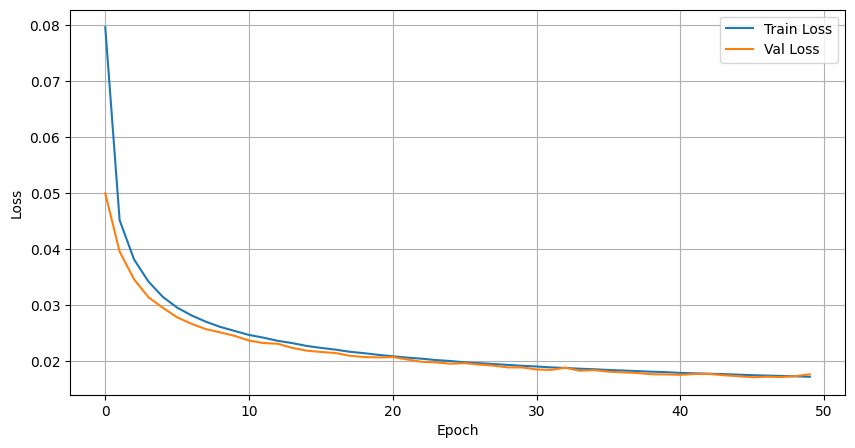

In [64]:
# Train and validation reconstruction loss.
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [65]:
# Extract the encoder's weights for transfer.
conv_state = model.encoder.state_dict()

In [66]:
# The classifier: identical encoder, new classification head.
# (inplace=True on the activations overwrites the input tensor instead of
# allocating a new one - a small memory saving, as the inline comment notes.)
class FmnistClassifier(nn.Module):
    def __init__(self, chan_num=16, latent_dim=128):
        super().__init__()


        self.encoder = nn.Sequential(
            # Block 1
            nn.Conv2d(1, chan_num, kernel_size=3, padding=1, stride=1),  # -> [B, C, 28, 28]
            nn.BatchNorm2d(chan_num),
            nn.LeakyReLU(0.2, inplace=True),  # Inplace just is an optimization thing, does not create a new tensor, just overwrites it.
            nn.AvgPool2d(2, 2),                                            # -> [B, C, 14, 14]

            # Block 2
            nn.Conv2d(chan_num, 2 * chan_num, kernel_size=3, padding=1, stride=1), # -> [B, 2C, 14, 14]
            nn.BatchNorm2d(2 * chan_num),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AvgPool2d(2, 2),                                            # -> [B, 2C, 7, 7]

            # Block 3
            nn.Conv2d(2 * chan_num, 4 * chan_num, kernel_size=3, padding=1, stride=1), # -> [B, 4C, 7, 7]
            nn.BatchNorm2d(4 * chan_num),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AvgPool2d(2, 2),                                            # -> [B, 4C, 3, 3]

        )

        self.linear_layers = nn.Sequential(
            nn.Flatten(),                                                  # -> [B, 4*C*3*3]
            nn.Linear(4 * chan_num * 3 * 3, latent_dim),
            nn.ReLU(inplace=True),
            nn.Linear(latent_dim,10)
        )


    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        z = self.encode(x)
        return self.linear_layers(z)

In [67]:
test_classifier = FmnistClassifier().to(device)
test_classifier

FmnistClassifier(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.2, inplace=True)
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (linear_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=576, out_features=128, bias=True)
 

In [68]:
# torchsummary for the classifier.
torchsummary.summary(test_classifier, (1,28,28),bs)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [32, 16, 28, 28]             160
       BatchNorm2d-2           [32, 16, 28, 28]              32
         LeakyReLU-3           [32, 16, 28, 28]               0
         AvgPool2d-4           [32, 16, 14, 14]               0
            Conv2d-5           [32, 32, 14, 14]           4,640
       BatchNorm2d-6           [32, 32, 14, 14]              64
         LeakyReLU-7           [32, 32, 14, 14]               0
         AvgPool2d-8             [32, 32, 7, 7]               0
            Conv2d-9             [32, 64, 7, 7]          18,496
      BatchNorm2d-10             [32, 64, 7, 7]             128
        LeakyReLU-11             [32, 64, 7, 7]               0
        AvgPool2d-12             [32, 64, 3, 3]               0
          Flatten-13                  [32, 576]               0
           Linear-14                  [

In [69]:
# Load the pretrained encoder into the classifier.
classifier = FmnistClassifier().to(device)

classifier.encoder.load_state_dict(conv_state)

<All keys matched successfully>

In [70]:
# Freeze the encoder, train the head.
for name, params in classifier.encoder.named_parameters():
  params.requires_grad = False

for name, params in classifier.linear_layers.named_parameters():
  params.requires_grad = True

In [71]:
# Verify which parameters are trainable.
for name, params in classifier.named_parameters():
   print(f'Name : {name} | Requires Grad : {params.requires_grad}')

Name : encoder.0.weight | Requires Grad : False
Name : encoder.0.bias | Requires Grad : False
Name : encoder.1.weight | Requires Grad : False
Name : encoder.1.bias | Requires Grad : False
Name : encoder.4.weight | Requires Grad : False
Name : encoder.4.bias | Requires Grad : False
Name : encoder.5.weight | Requires Grad : False
Name : encoder.5.bias | Requires Grad : False
Name : encoder.8.weight | Requires Grad : False
Name : encoder.8.bias | Requires Grad : False
Name : encoder.9.weight | Requires Grad : False
Name : encoder.9.bias | Requires Grad : False
Name : linear_layers.1.weight | Requires Grad : True
Name : linear_layers.1.bias | Requires Grad : True
Name : linear_layers.3.weight | Requires Grad : True
Name : linear_layers.3.bias | Requires Grad : True


In [72]:
# Verify the copied weights are identical tensor by tensor. Do this check every
# time - a failed transfer looks exactly like a transfer that did not help.
# Checking if the encoder layers match

for source, target in zip(model.encoder.parameters() , classifier.encoder.parameters()):
  print(torch.equal(source,target))

True
True
True
True
True
True
True
True
True
True
True
True


In [73]:
print('Now we have confirmed layers in the encoder are frozen and equal to the AE')

Now we have confirmed layers in the encoder are frozen and equal to the AE


In [82]:
# STAGE 2: supervised training of the head.
# lr=1e-5 is very small for a randomly initialised head on frozen features; 1e-3
# would likely converge much faster here. Worth trying both.
# Note this loops over the whole validation loader rather than taking one batch,
# which is the more careful pattern.
def train_classifier(epochs=10, lr=1e-5):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(classifier.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        classifier.train()
        batch_losses = []
        correct_train = 0
        total_train = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            preds = classifier(x)
            loss = loss_fn(preds, y)
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

            _, predicted = torch.max(preds.data, 1)
            total_train += y.size(0)
            correct_train += (predicted == y).sum().item()

        avg_train_loss = np.mean(batch_losses)
        train_losses.append(avg_train_loss)

        train_acc = correct_train / total_train
        train_accuracies.append(train_acc)

        # Validation phase
        classifier.eval()
        val_batch_losses = []
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val, y_val = x_val.to(device), y_val.to(device)
                val_preds = classifier(x_val)
                val_loss = loss_fn(val_preds, y_val)
                val_batch_losses.append(val_loss.item())

                _, predicted = torch.max(val_preds.data, 1)
                total_val += y_val.size(0)
                correct_val += (predicted == y_val).sum().item()

        avg_val_loss = np.mean(val_batch_losses)
        val_losses.append(avg_val_loss)

        val_acc = correct_val / total_val
        val_accuracies.append(val_acc)

        print(f'Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.6f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.6f} | Val Acc: {val_acc:.4f}')

    return classifier, train_losses, val_losses, train_accuracies, val_accuracies


In [83]:
# Train. Compare the first-epoch accuracy against a from-scratch model: a
# pretrained encoder starts far ahead, and that head start is the entire point.
classifier, train_losses, val_losses, train_accuracies, val_accuracies = train_classifier()

Epoch   1/10 | Train Loss: 0.248738 | Train Acc: 0.9077 | Val Loss: 0.305810 | Val Acc: 0.8878
Epoch   2/10 | Train Loss: 0.248561 | Train Acc: 0.9083 | Val Loss: 0.305615 | Val Acc: 0.8880
Epoch   3/10 | Train Loss: 0.247668 | Train Acc: 0.9084 | Val Loss: 0.305823 | Val Acc: 0.8875
Epoch   4/10 | Train Loss: 0.247956 | Train Acc: 0.9083 | Val Loss: 0.305446 | Val Acc: 0.8890
Epoch   5/10 | Train Loss: 0.247863 | Train Acc: 0.9079 | Val Loss: 0.304941 | Val Acc: 0.8880
Epoch   6/10 | Train Loss: 0.247591 | Train Acc: 0.9085 | Val Loss: 0.305748 | Val Acc: 0.8882
Epoch   7/10 | Train Loss: 0.247741 | Train Acc: 0.9081 | Val Loss: 0.305526 | Val Acc: 0.8872
Epoch   8/10 | Train Loss: 0.247198 | Train Acc: 0.9092 | Val Loss: 0.304765 | Val Acc: 0.8888
Epoch   9/10 | Train Loss: 0.247530 | Train Acc: 0.9086 | Val Loss: 0.304797 | Val Acc: 0.8878
Epoch  10/10 | Train Loss: 0.247172 | Train Acc: 0.9088 | Val Loss: 0.304874 | Val Acc: 0.8898


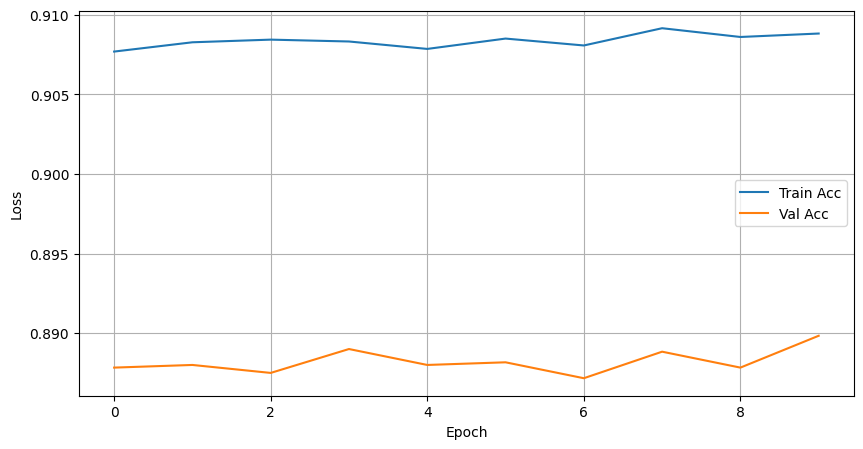

In [84]:
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

#### In this case the pretraining is not working, because the model does not learn the fetures required for classification in the pretraing phase..

#### So it not always useful to pretrain.